# **Proyecto de Taxis "Zuber"**

**Descripción del Proyecto**

Este proyecto analiza datos de viajes de taxis en Chicago a partir de tres conjuntos de datos: uno con información sobre las compañías de taxis, otro sobre los barrios donde finalizan los viajes y un tercero con datos de duración de viajes desde el Loop hasta el Aeropuerto Internacional O'Hare.

El objetivo es explorar y comprender los patrones de uso de los taxis, identificando tendencias en la distribución de viajes según compañías, ubicaciones y condiciones externas como el clima.

El análisis incluye:
- Verificación de tipos de datos y detección de posibles errores
- Exploración y limpieza de los datos
- Análisis de las compañías de taxis según el número de viajes
- Identificación de los 10 barrios con mayor número de finalizaciones
- Creación de visualizaciones para destacar patrones relevantes
- Generación de conclusiones basadas en los resultados obtenidos

Adicionalmente, se realiza una prueba de hipótesis para evaluar si la duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia durante los sábados lluviosos.

Para ello:
- Se plantean hipótesis nula y alternativa
- Se utiliza una prueba estadística (t-test) para comparar medias
- Se establece un nivel de significación (α = 0.05)
- Se interpreta el valor p para aceptar o rechazar la hipótesis

El propósito final es obtener insights que permitan entender mejor el comportamiento de los viajes en la ciudad, identificar factores que influyen en su duración y destacar las áreas y empresas con mayor actividad.

**Análisis Exploratorio de Datos**

In [77]:
#Importación de las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt

In [78]:
#Carga de los datos desde los archivos CSV
companies_data = pd.read_csv('data/moved_project_sql_result_01.csv')
neighborhoods_data = pd.read_csv('data/moved_project_sql_result_04.csv')

In [79]:
#Estudio de los datos
print("Companies Data:")
print(companies_data.head(20))
print()
print("Neighborhoods Data:")
print(neighborhoods_data.head(20))

Companies Data:
                            company_name  trips_amount
0                              Flash Cab         19558
1              Taxi Affiliation Services         11422
2                       Medallion Leasin         10367
3                             Yellow Cab          9888
4        Taxi Affiliation Service Yellow          9299
5              Chicago Carriage Cab Corp          9181
6                           City Service          8448
7                               Sun Taxi          7701
8              Star North Management LLC          7455
9      Blue Ribbon Taxi Association Inc.          5953
10               Choice Taxi Association          5015
11                            Globe Taxi          4383
12             Dispatch Taxi Affiliation          3355
13             Nova Taxi Affiliation Llc          3175
14  Patriot Taxi Dba Peace Taxi Associat          2235
15              Checker Taxi Affiliation          2216
16                          Blue Diamond         

In [80]:
#Información general de los datos
print("Companies Info:")
print(companies_data.info())
print()
print("Neighborhoods Info:")
print(neighborhoods_data.info())

Companies Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None

Neighborhoods Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


El primer Data Set "companies_data" ofrece información acerca de las empresas de taxis y el número de viajes que han hecho, mientras que el segundo "neighborhoods_data" ofrece información acerca de los barrios de la ciudad de Chicago con el promedio de viajes realizados. Los tipos de datos son correctos y no tenemos valores nulos. 

In [81]:
#10 principales barrios por finalización de recorridos
top_10_neighborhoods = neighborhoods_data.head(10)
print("Los 10 principales barrios en términos de finalización del recorrido:")
print(top_10_neighborhoods)

Los 10 principales barrios en términos de finalización del recorrido:
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


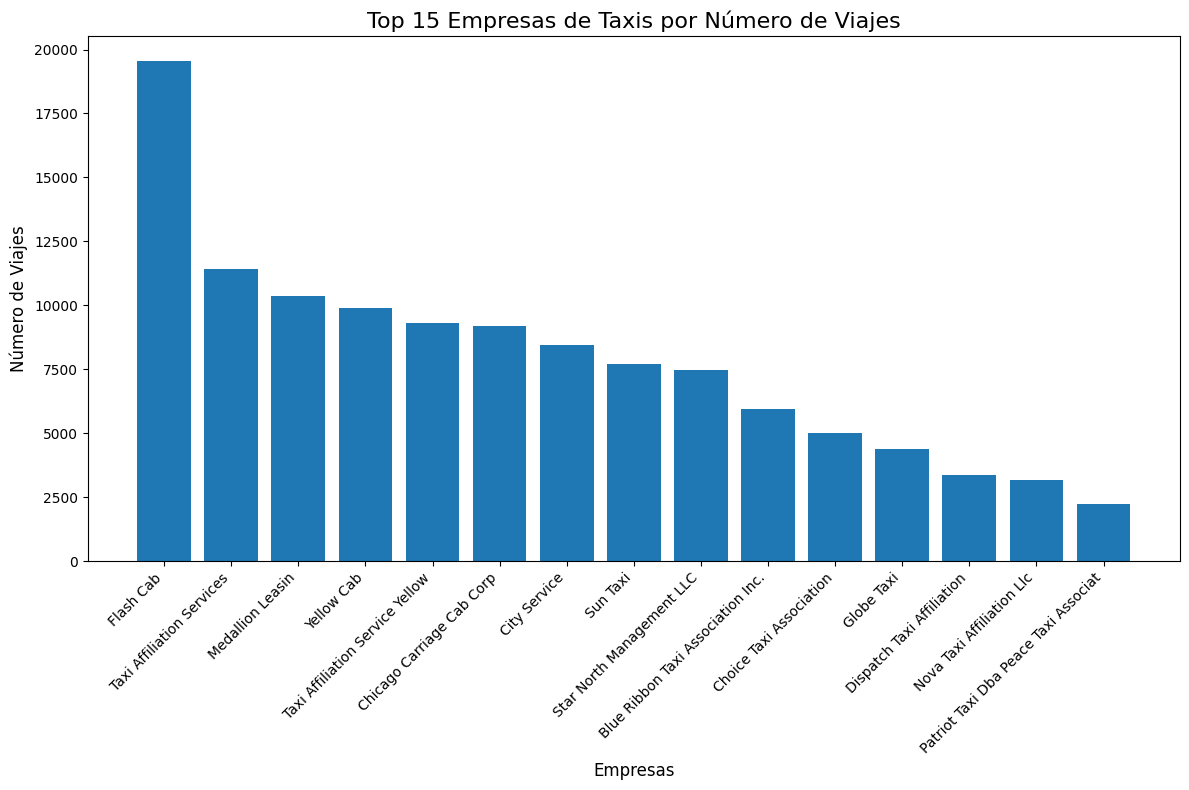

In [82]:
#Gráfico 1: Top 15 empresas de taxis por número de viajes
top_15_companies = companies_data.head(15)

plt.figure(figsize=(12, 8))
plt.bar(range(len(top_15_companies)), top_15_companies['trips_amount'])
plt.title('Top 15 Empresas de Taxis por Número de Viajes', fontsize=16)
plt.xlabel('Empresas', fontsize=12)
plt.ylabel('Número de Viajes', fontsize=12)
plt.xticks(range(len(top_15_companies)), top_15_companies['company_name'], rotation=45, ha='right')
plt.tight_layout()
plt.show()

Tenemos información de 64 empresas de taxis, pero he seleccionado las top 15 para el análisis por cuestiones de legibilidad del gráfico y relevancia de la información. Los resultados muestran una distribución desigual en el mercado de taxis. Flash Cab domina claramente el mercado con 19,558 viajes, superando por 8,136 viajes a la segunda empresa, Taxi Affiliation Services. Las empresas del 2º al 15º lugar (desde Taxi Affiliation Services hasta Patriot Taxi) muestran una competencia más equilibrada, con diferencias menores entre ellas. Existe una brecha significativa entre el líder del mercado y el resto de competidores, lo que sugiere una posible concentración de mercado.

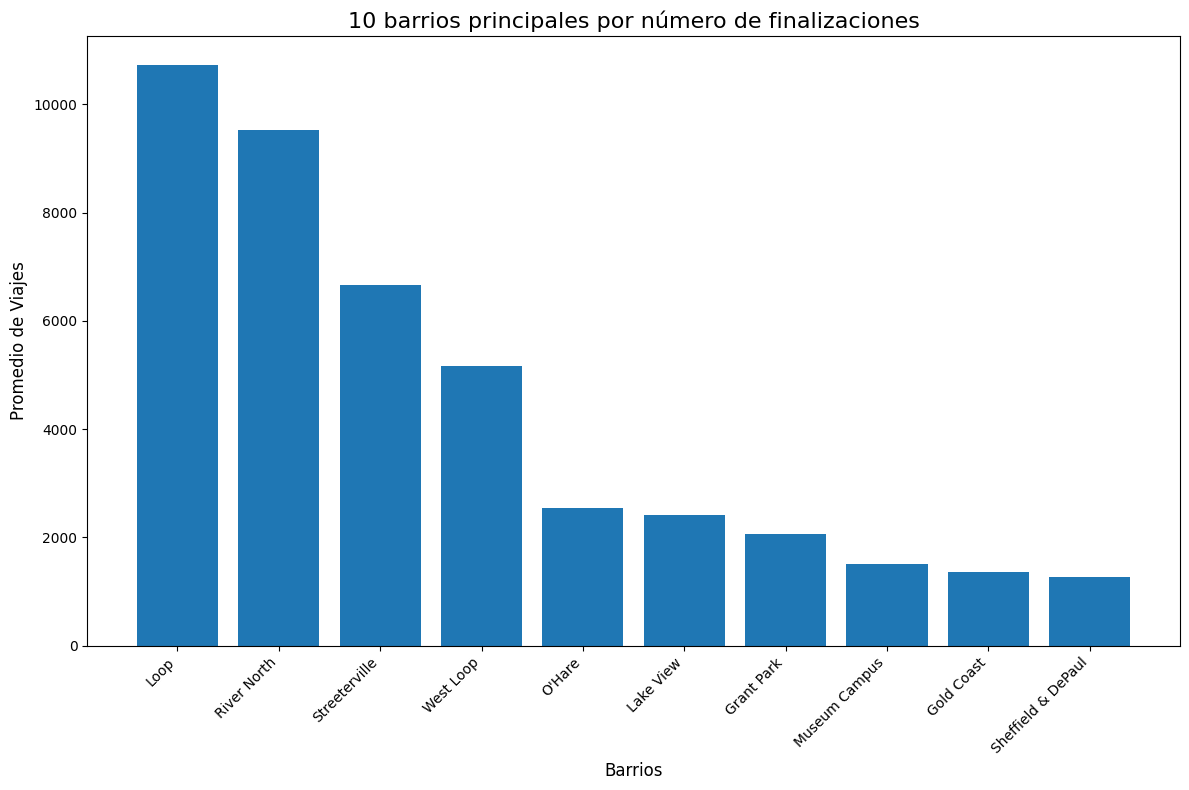

In [83]:
#Gráfico 2: 10 barrios principales por número de finalizaciones
plt.figure(figsize=(12, 8))
plt.bar(range(len(top_10_neighborhoods)), top_10_neighborhoods['average_trips'])
plt.title('10 barrios principales por número de finalizaciones', fontsize=16)
plt.xlabel('Barrios', fontsize=12)
plt.ylabel('Promedio de Viajes', fontsize=12)
plt.xticks(range(len(top_10_neighborhoods)), top_10_neighborhoods['dropoff_location_name'], rotation=45, ha='right')
plt.tight_layout()
plt.show()

Podemos evidenciar que el barrio principal por número de finalizaciones es Loop con 10,727.47 viajes promedio, seguido por River North con 9,523.67 viajes promedio. Existe una diferencia significativa de 1,203.8 viajes entre el primer y segundo lugar. Los barrios que completan el top 5 son: Streeterville: 6,664.67 viajes, West Loop: 5,163.67 viajes, O'Hare: 2,546.90 viajes. Los barrios con menor número de finalizaciones dentro del top 10 son Museum Campus (1,510.00 viajes), Gold Coast (1,364.23 viajes) y Sheffield & DePaul (1,259.77 viajes).

**Prueba de hipótesis**

In [84]:
#Carga del dataset de viajes Loop-O'Hare
trips_data = pd.read_csv('/datasets/project_sql_result_07.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/datasets/project_sql_result_07.csv'

In [ ]:
#Exploración de la estructura de los datos
print("Información general del dataset:")
print(trips_data.info())
print()
print("\nPrimeras filas:")
print(trips_data.head(10))
print()
print("\nEstadísticas descriptivas:")
print(trips_data.describe())